# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [2]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

In [3]:
df = pd.read_csv("breast-cancer-wisconsin-data.csv")
df.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [4]:
# Checking target varaible distribution
df['Class'].value_counts()

2    458
4    241
Name: Class, dtype: int64

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [5]:
# Print data types for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


In [6]:
# Print dataframe shape
df.shape

(699, 11)

# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [7]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [8]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?


In [9]:
# Checking column with object values as all supposed to be numerical (no other values missing)
df['Bare Nuclei'].value_counts()

1     402
10    132
2      30
5      30
3      28
8      21
4      19
?      16
9       9
7       8
6       4
Name: Bare Nuclei, dtype: int64

In [10]:
# Dropping rows with '?' as the same can be ignored for the study 
df = df[df['Bare Nuclei'] != '?']
df = df.convert_objects(convert_numeric=True)

C:\Users\Jatin_Thakkar\AppData\Local\Continuum\anaconda3\lib\site-packages\ipykernel_launcher.py:3: FutureWarning: convert_objects is deprecated.  To re-infer data dtypes for object columns, use DataFrame.infer_objects()
For all other conversions use the data-type specific converters pd.to_datetime, pd.to_timedelta and pd.to_numeric.
  This is separate from the ipykernel package so we can avoid doing imports until


In [11]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [12]:
# Remove duplicate rows
df = df.drop_duplicates()
df.shape

(675, 11)

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [13]:
# Check for correlation of variable

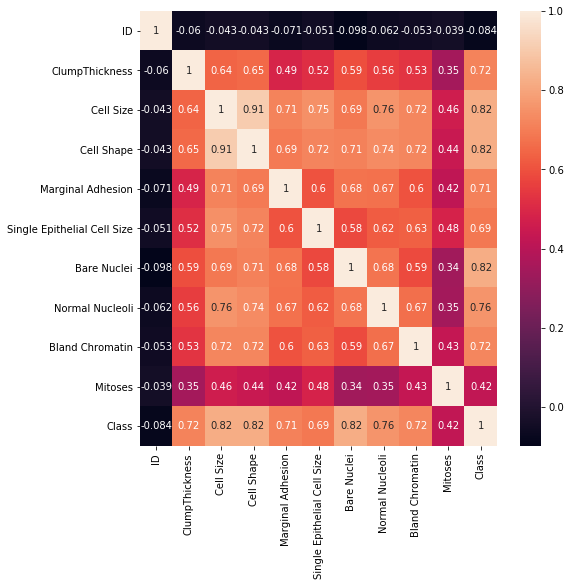

In [14]:
corr = df.corr()
plt.figure(figsize=(8,8)) 
sns.heatmap(corr, annot=True)

In [15]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, 
# normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [16]:
#Let us check for pair plots

C:\Users\Jatin_Thakkar\AppData\Local\Continuum\anaconda3\lib\site-packages\statsmodels\nonparametric\kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
C:\Users\Jatin_Thakkar\AppData\Local\Continuum\anaconda3\lib\site-packages\statsmodels\nonparametric\kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2


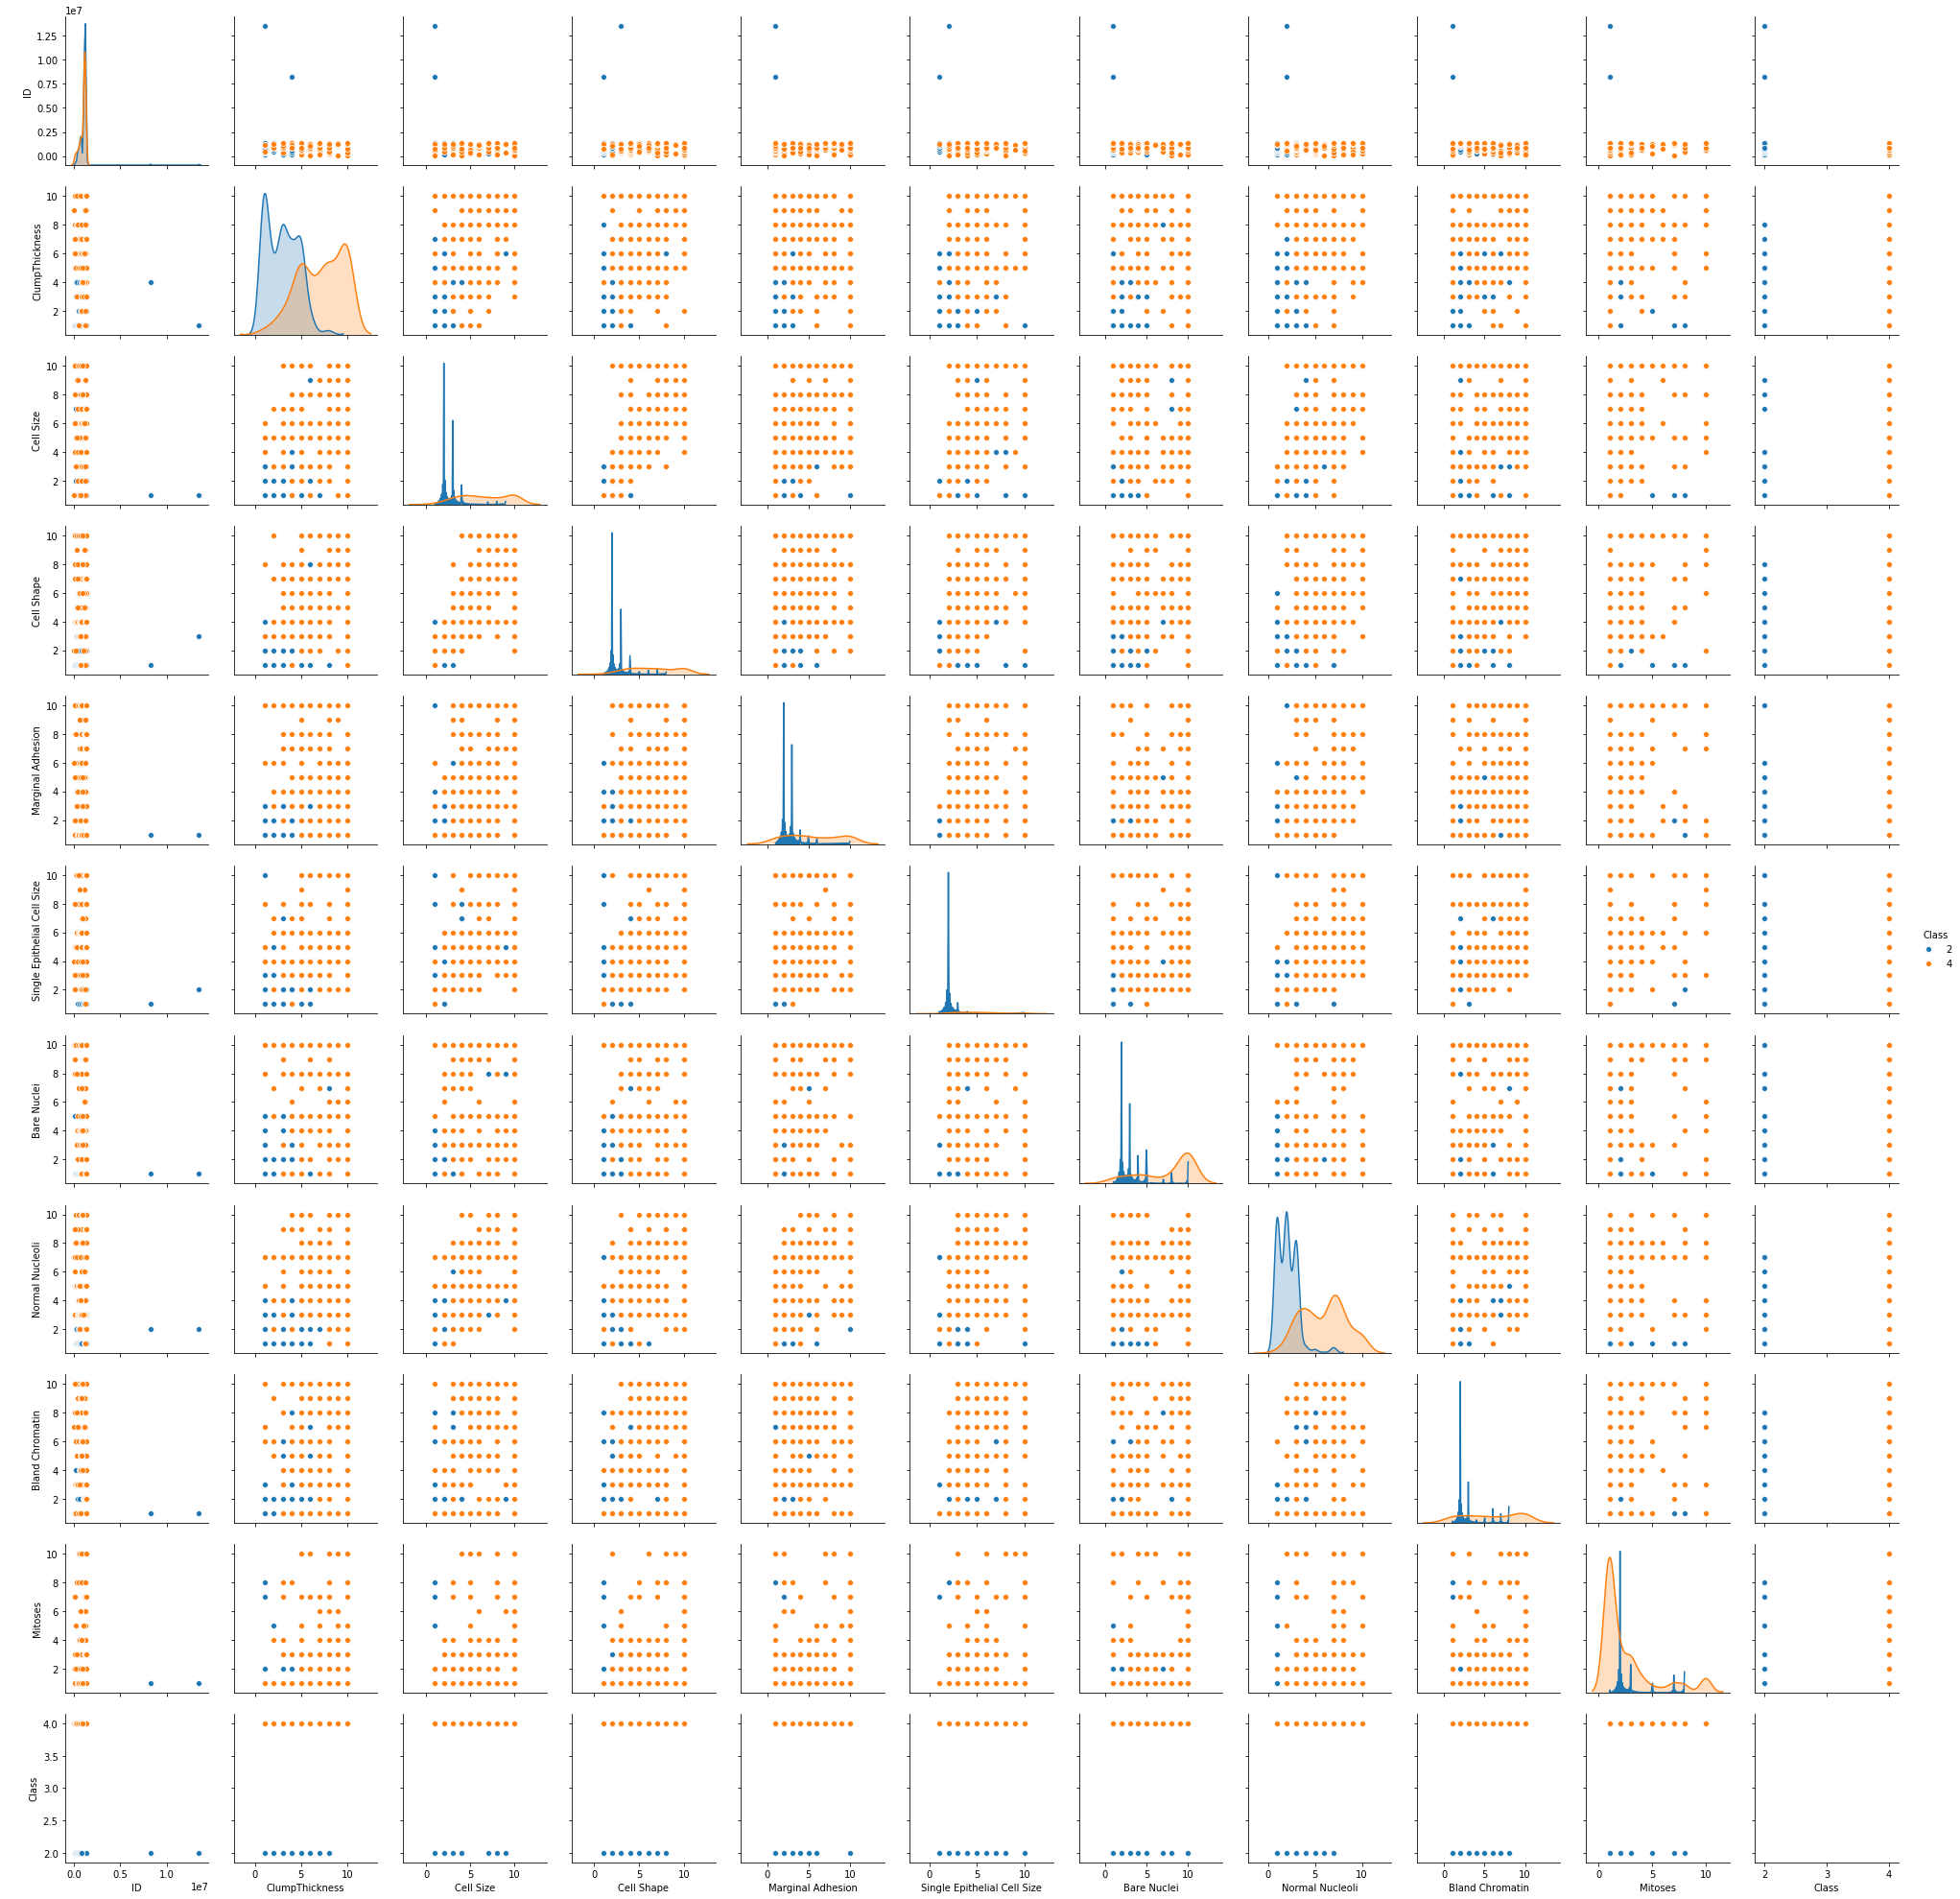

In [17]:
# Pairplot using sns
sns.pairplot(df,diag_kind="kde", hue="Class")

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [18]:
# dropping ID column as same is not required for analysis
df = df.drop('ID', 1)

In [19]:
# checking for outliers
df.describe(include="all")

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000,675.000000
mean,4.451852,3.146667,3.208889,2.848889,3.229630,3.537778,3.442963,2.885926,1.607407,2.699259
std,2.820859,3.055005,2.976552,2.875917,2.208497,3.637871,2.453894,3.065607,1.741006,0.954413
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [20]:
# As observed in pairplot, high-end values for most of the columns (all of them seem to ordinal rather than numeric)
# belong to class '2' and else belongs to '4'
# Conclusion - No outlier treatment

In [21]:
# test-checking if the outlier values are actually dropped (following values based on box plot analysis):
#Marginal Adhesion > 7
#Single Epithelial Cell Size > 7
#Normal Nucleoli > 9
#Bland Chromatin > 8
#drop Mitoses column as the same has either 1 or outliers
df_1 = df[df['Marginal Adhesion'] > 7]
df_2 = df_1[df_1['Single Epithelial Cell Size'] > 9]
df_3 = df_2[df_2['Normal Nucleoli'] > 9]
df_4 = df_3[df_3['Bland Chromatin'] > 8]
df_without_outliers = df_4.drop('Mitoses', 1)
df_without_outliers.shape

(3, 9)

In [22]:
# NOTE: The shape of the data reduces drastically if outlier treatment applied, 
# another reason why no outlier treatment needs to be done in this case

In [23]:
# Identifying independent variables
X = df.drop(['Class'], axis=1)

In [24]:
# Standardize variables
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

In [25]:
X = pd.DataFrame(scaled_X)
X.columns = ['ClumpThickness','Cell_Size','Cell_Shape','Marginal_Adhesion','Single_Epithelial_Cell_Size','Bare_Nuclei','Normal_Nucleoli','Bland_Chromatin','Mitoses']
X.head()

,ClumpThickness,Cell_Size,Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Normal_Nucleoli,Bland_Chromatin,Mitoses
0,0.194464,-0.703193,-0.742647,-0.643363,-0.557185,-0.698117,-0.180648,-0.615645,-0.349142
1,0.194464,0.279530,0.265978,0.748529,1.708477,1.777692,-0.180648,-0.289203,-0.349142
2,-0.515066,-0.703193,-0.742647,-0.643363,-0.557185,-0.423027,-0.180648,-0.615645,-0.349142
3,0.549228,1.589828,1.610811,-0.643363,-0.104053,0.127153,-0.180648,1.343005,-0.349142
4,-0.160301,-0.703193,-0.742647,0.052583,-0.557185,-0.698117,-0.180648,-0.615645,-0.349142


# Q6 Create a covariance matrix for identifying Principal components

In [26]:
# PCA
# Step 1 - Create covariance matrix
# Obtain covariance matrix for X (note columns are the features)
cov_matrix = np.cov(X, rowvar=False)
# Note that covariance matrix is 9x9 since their are 8 features
print('Covariance matrix of X: \n%s' %cov_matrix)

Covariance matrix of X: 
[[1.00148368 0.64179757 0.6535854  0.49014737 0.51994192 0.59481694
  0.55722956 0.53468337 0.35179132]
 [0.64179757 1.00148368 0.9070993  0.71571019 0.7499397  0.69091892
  0.76054465 0.72478554 0.46287028]
 [0.6535854  0.9070993  1.00148368 0.69505865 0.71825054 0.71193067
  0.73896771 0.72431427 0.44367028]
 [0.49014737 0.71571019 0.69505865 1.00148368 0.60437455 0.67743141
  0.67274039 0.60308103 0.41901379]
 [0.51994192 0.7499397  0.71825054 0.60437455 1.00148368 0.58361701
  0.62357253 0.6350697  0.4849303 ]
 [0.59481694 0.69091892 0.71193067 0.67743141 0.58361701 1.00148368
  0.68014431 0.58882248 0.34029648]
 [0.55722956 0.76054465 0.73896771 0.67274039 0.62357253 0.68014431
  1.00148368 0.66981274 0.34619368]
 [0.53468337 0.72478554 0.72431427 0.60308103 0.6350697  0.58882248
  0.66981274 1.00148368 0.43368123]
 [0.35179132 0.46287028 0.44367028 0.41901379 0.4849303  0.34029648
  0.34619368 0.43368123 1.00148368]]


# Q7 Identify eigen values and eigen vector

In [27]:
# Step 2- Get eigen values and eigen vector

In [28]:
# Obtain eigenvalues and eigenvectors 
eigenvalues, eigenvectors, = np.linalg.eig(cov_matrix)
# eigenvectors is a 9x9 matrix
print('Eigenvectors of Cov(X): \n%s' %eigenvectors)
# eigenvalues is a 9x1 vector
print('\nEigenvalues of Cov(X): \n%s' %eigenvalues)

Eigenvectors of Cov(X): 
[[-0.30129202  0.14382106 -0.87456587 -0.00397982 -0.0422162   0.01765212
  -0.27456474 -0.17685689  0.12206293]
 [-0.38047894  0.04530412  0.03820758 -0.73413297  0.187475   -0.1383224
   0.43174719 -0.26065752 -0.06437646]
 [-0.37721535  0.08032574 -0.01879307  0.66652232  0.1647692  -0.09050931
   0.58175214 -0.18009963 -0.02095043]
 [-0.33424356  0.05792885  0.38087816  0.04499803 -0.51017646 -0.02771199
  -0.24523402 -0.44650274  0.46613314]
 [-0.33574224 -0.17428826  0.13741306  0.06555505  0.37847261 -0.68074099
  -0.39574476  0.25535452  0.07246576]
 [-0.33444941  0.26083232 -0.02540712 -0.07399867 -0.51594288 -0.04672706
   0.18973227  0.71329136 -0.02872983]
 [-0.34620359  0.22791437  0.19876053  0.06603364  0.00423114  0.23600622
  -0.3625948  -0.14732488 -0.75857463]
 [-0.336225   -0.02954431  0.1366274  -0.02359043  0.45074714  0.65585696
  -0.11078206  0.26956903  0.38548003]
 [-0.23014187 -0.90345301 -0.10272634  0.00811798 -0.25102302  0.1419733

# Q8 Find variance and cumulative variance by each eigen vector

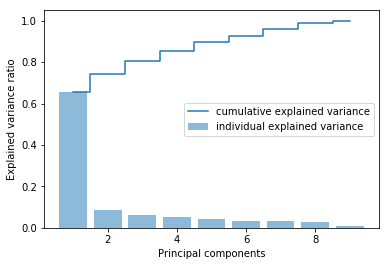

In [29]:
tot = sum(eigenvalues)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)]  # an array of variance explained by each 
# eigen vector... there will be 8 entries as there are 8 eigen vectors)
cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 8 entries with 8 th entry 
# cumulative reaching almost 100%
plt.bar(range(1,10), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,10),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()


# The plot shows that the first principal component alone accounts for 40 percent of the variance. 
# Also, we can see that the first two principal components combined explain almost 60 percent of the variance 
# in the data.

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [30]:
from sklearn.decomposition import PCA
# Make an instance of the Model
pca = PCA(n_components=9)
pca.fit(X)

PCA(copy=True, iterated_power='auto', n_components=9, random_state=None,
    svd_solver='auto', tol=0.0, whiten=False)

In [31]:
pca.explained_variance_ratio_

array([0.65673154, 0.08632848, 0.059996  , 0.0509305 , 0.04120188,
       0.03334313, 0.03242593, 0.02906028, 0.00998226])

# Q10 Find correlation between components and features

In [32]:
X_PCA_components = pca.transform(X)

In [33]:
X_PCA_components = pd.DataFrame(X_PCA_components)
X_PCA_components.columns = ['PC1','PC2','PC3','PC4','PC5','PC6','PC7','PC8','PC9']
X_PCA_components.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,-1.474581,-0.106656,-0.571006,0.024510,-0.101687,-0.218338,0.272382,-0.429480,-0.006416
1,1.443493,-0.554075,0.270757,-0.607916,1.608025,1.154890,-0.510920,-0.222808,0.022512
2,-1.596353,-0.076363,0.042535,-0.087467,-0.076308,0.103367,0.366893,-0.182474,0.011116
3,1.479207,-0.529020,-0.528985,1.455757,-0.515329,-0.070272,-0.338146,1.592522,0.187315
4,-1.348854,-0.095949,0.004330,-0.315568,-0.076139,-0.466337,-0.008718,-0.502743,-0.039144


In [34]:
overall_corr_df = pd.concat([X, X_PCA_components], axis=1, sort=False)
overall_corr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 675 entries, 0 to 674
Data columns (total 18 columns):
ClumpThickness                 675 non-null float64
Cell_Size                      675 non-null float64
Cell_Shape                     675 non-null float64
Marginal_Adhesion              675 non-null float64
Single_Epithelial_Cell_Size    675 non-null float64
Bare_Nuclei                    675 non-null float64
Normal_Nucleoli                675 non-null float64
Bland_Chromatin                675 non-null float64
Mitoses                        675 non-null float64
PC1                            675 non-null float64
PC2                            675 non-null float64
PC3                            675 non-null float64
PC4                            675 non-null float64
PC5                            675 non-null float64
PC6                            675 non-null float64
PC7                            675 non-null float64
PC8                            675 non-null float64
PC9        

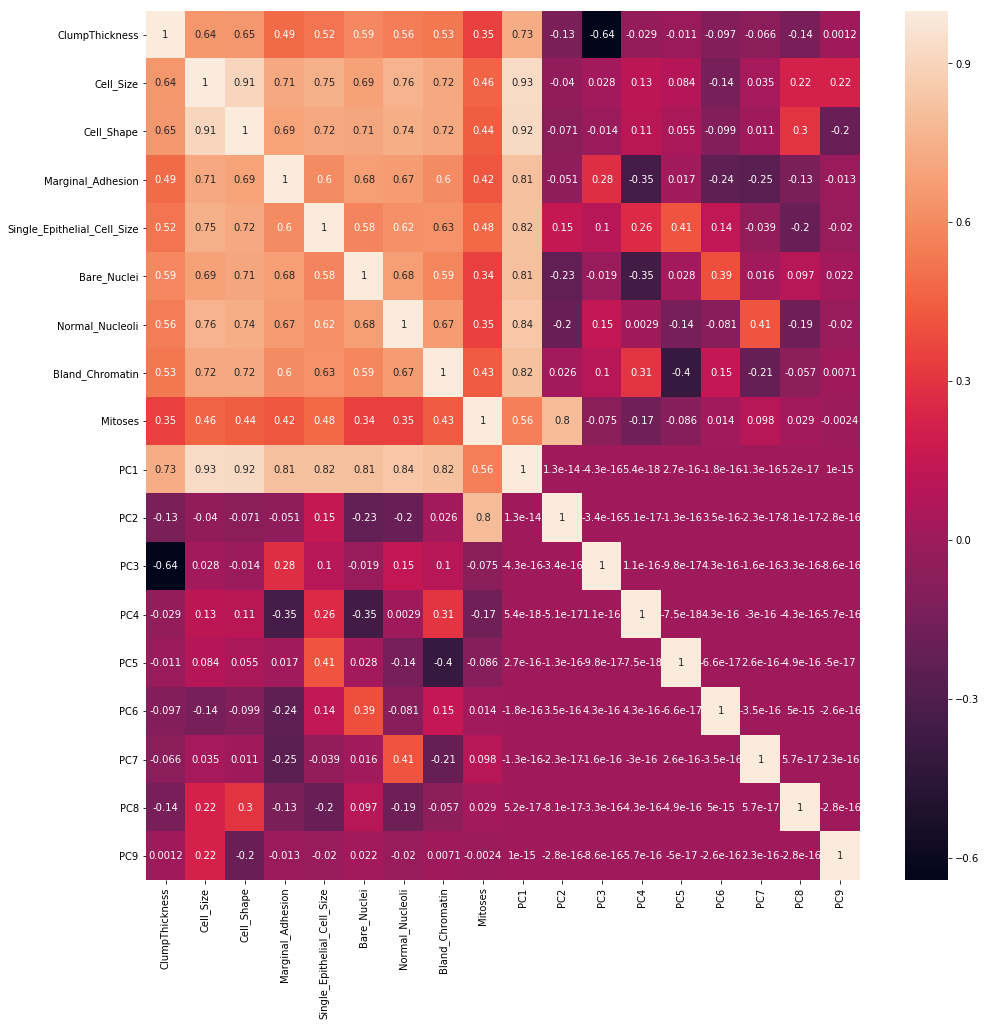

In [35]:
corr = overall_corr_df.corr()
plt.figure(figsize=(16,16)) 
sns.heatmap(corr, annot=True)